<a href="https://colab.research.google.com/github/Fidan6557/bank-marketing-ml-prediction/blob/main/bank_marketing_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing Campaign Success Prediction

This project builds a machine learning pipeline to predict whether a bank client is likely to subscribe to a term deposit.

The project focuses on realistic pre-call prediction. Therefore, the `duration` feature is excluded from the final model because it is only available after the phone call and would cause data leakage.

In [3]:
# ============================================================
# Bank Marketing Campaign Success Prediction
# End-to-End Machine Learning Project - Improved Senior ML Version
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve
)

# XGBoost usually exists in Google Colab. If not, the code will continue without it.
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not installed. The notebook will continue without XGBoost.")

import joblib

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


In [4]:
# ============================================================
# Download and Extract Dataset
# ============================================================

DATA_DIR = "data"
RAW_DIR = os.path.join(DATA_DIR, "raw")

os.makedirs(RAW_DIR, exist_ok=True)

main_zip_url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
main_zip_path = os.path.join(RAW_DIR, "bank_marketing.zip")

if not os.path.exists(main_zip_path):
    urllib.request.urlretrieve(main_zip_url, main_zip_path)
    print("Main zip file downloaded.")
else:
    print("Main zip file already exists.")

with zipfile.ZipFile(main_zip_path, "r") as zip_ref:
    zip_ref.extractall(RAW_DIR)

# The main zip contains another zip file for bank-additional data.
additional_zip_path = os.path.join(RAW_DIR, "bank-additional.zip")

if os.path.exists(additional_zip_path):
    with zipfile.ZipFile(additional_zip_path, "r") as zip_ref:
        zip_ref.extractall(RAW_DIR)
    print("Bank additional zip extracted.")
else:
    print("bank-additional.zip was not found. Check extracted files below.")


Main zip file downloaded.
Bank additional zip extracted.


In [5]:
for root, dirs, files in os.walk(RAW_DIR):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

data/raw/bank-additional/bank-additional-full.csv
data/raw/bank-additional/bank-additional.csv


In [6]:
csv_path = None

for root, dirs, files in os.walk(RAW_DIR):
    for file in files:
        if file == "bank-additional-full.csv":
            csv_path = os.path.join(root, file)

print("CSV path:", csv_path)

df = pd.read_csv(csv_path, sep=";")

print("Dataset shape:", df.shape)
df.head()

CSV path: data/raw/bank-additional/bank-additional-full.csv
Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
# ============================================================
# Let's explore basic dataset information
# ============================================================

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (41188, 21)

Columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
# ============================================================
# Missing Value Analysis
# ============================================================

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": (missing_values / len(df)) * 100
})

missing_df

,missing_count,missing_percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
month,0,0.0
day_of_week,0,0.0


In [9]:
# ============================================================
# Unknown Value Analysis
# ============================================================

unknown_counts = {}

for col in df.select_dtypes(include="object").columns:
    unknown_counts[col] = (df[col] == "unknown").sum()

unknown_df = pd.DataFrame.from_dict(
    unknown_counts,
    orient="index",
    columns=["unknown_count"]
)

unknown_df["unknown_percentage"] = unknown_df["unknown_count"] / len(df) * 100

unknown_df = unknown_df.sort_values(by="unknown_percentage", ascending=False)

unknown_df

,unknown_count,unknown_percentage
default,8597,20.872584
education,1731,4.202680
housing,990,2.403613
loan,990,2.403613
job,330,0.801204
marital,80,0.194231
contact,0,0.000000
month,0,0.000000
day_of_week,0,0.000000
poutcome,0,0.000000


In [10]:
# ============================================================
# Duplicate Rows
# ============================================================

duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
    print("New dataset shape:", df.shape)

Number of duplicate rows: 12
Duplicates removed.
New dataset shape: (41176, 21)


In [11]:
# ============================================================
# Target Variable Distribution
# ============================================================

target_counts = df["y"].value_counts()
target_percentages = df["y"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

target_summary

,count,percentage
y,,
no,36537,88.733728
yes,4639,11.266272


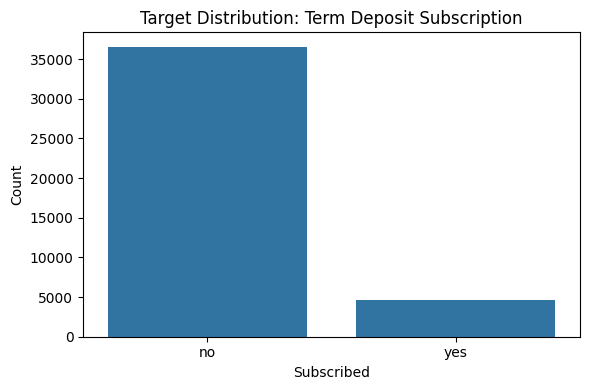

In [12]:
# ============================================================
# Target Distribution Visualization
# ============================================================

# Define FIGURE_DIR and create the directory if it doesn't exist
FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Target Distribution: Term Deposit Subscription")
plt.xlabel("Subscribed")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "target_distribution.png"), dpi=300)
plt.show()

In [13]:
# ============================================================
# Separate Numerical and Categorical Features
# ============================================================

target_col = "y"

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

categorical_cols.remove(target_col)

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [14]:
# ============================================================
# Numerical Feature Summary
# ============================================================

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


In [ ]:
# ============================================================
# Categorical Feature Summary
# ============================================================

for col in categorical_cols:
    print("=" * 70)
    print(col)
    print(df[col].value_counts(normalize=True).head(10) * 100)

job
job
admin.           25.303575
blue-collar      22.471828
technician       16.366330
services          9.634253
management        7.101224
retired           4.172333
entrepreneur      3.536040
self-employed     3.451039
housemaid         2.574315
unemployed        2.462600
Name: proportion, dtype: float64
marital
marital
married     60.523120
single      28.084321
divorced    11.198271
unknown      0.194288
Name: proportion, dtype: float64
education
education
university.degree      29.541480
high.school            23.100835
basic.9y               14.680882
professional.course    12.725860
basic.4y               10.141830
basic.6y                5.563921
unknown                 4.201477
illiterate              0.043715
Name: proportion, dtype: float64
default
default
no         79.116476
unknown    20.876239
yes         0.007286
Name: proportion, dtype: float64
housing
housing
yes        52.387313
no         45.208374
unknown     2.404313
Name: proportion, dtype: float64
loan
loan
n

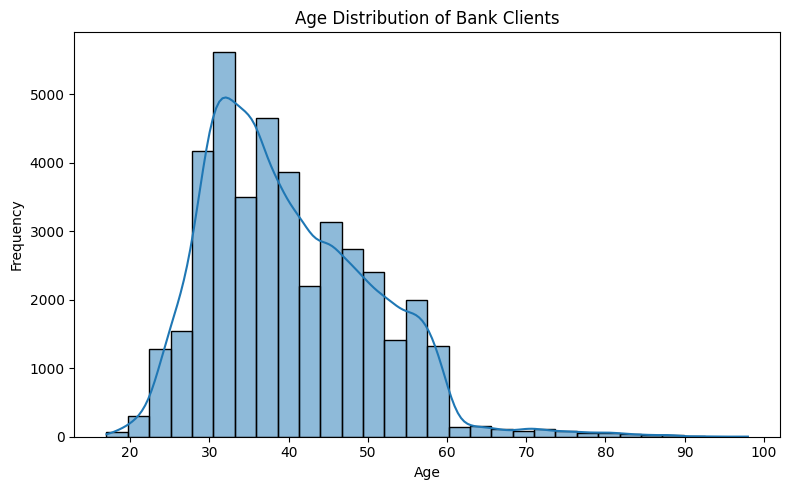

In [15]:
# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution of Bank Clients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "age_distribution.png"), dpi=300)
plt.show()

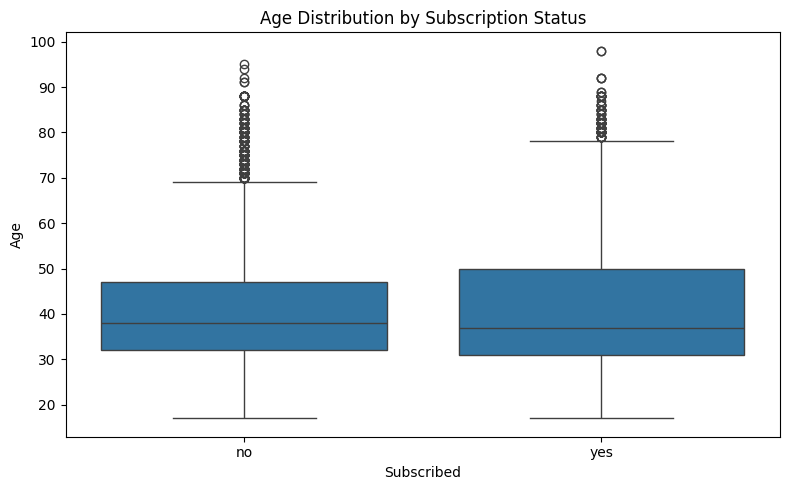

In [16]:
# ============================================================
# Age Distribution by Subscription Status
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="y", y="age")
plt.title("Age Distribution by Subscription Status")
plt.xlabel("Subscribed")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "age_by_subscription.png"), dpi=300)
plt.show()

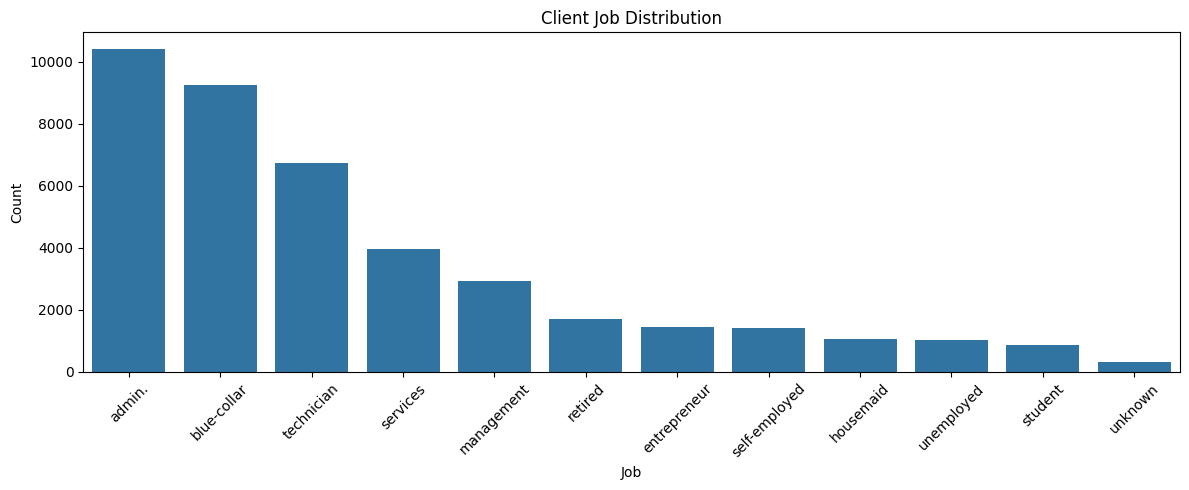

In [17]:
# ============================================================
# Job Distribution
# ============================================================

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="job", order=df["job"].value_counts().index)
plt.title("Client Job Distribution")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "job_distribution.png"), dpi=300)
plt.show()

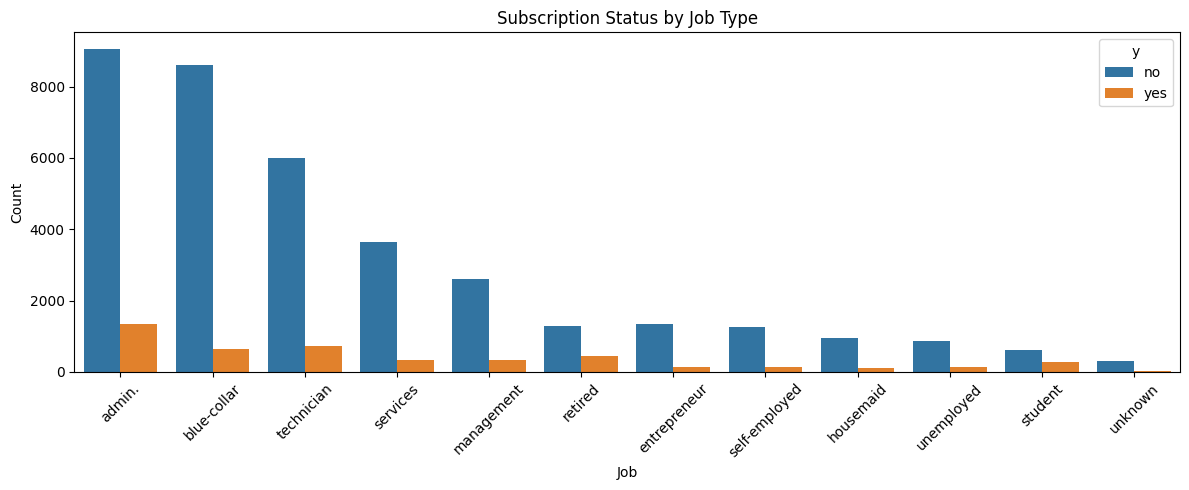

In [18]:
# ============================================================
# Subscription Status by Job Type
# ============================================================

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="job", hue="y", order=df["job"].value_counts().index)
plt.title("Subscription Status by Job Type")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "subscription_by_job.png"), dpi=300)
plt.show()

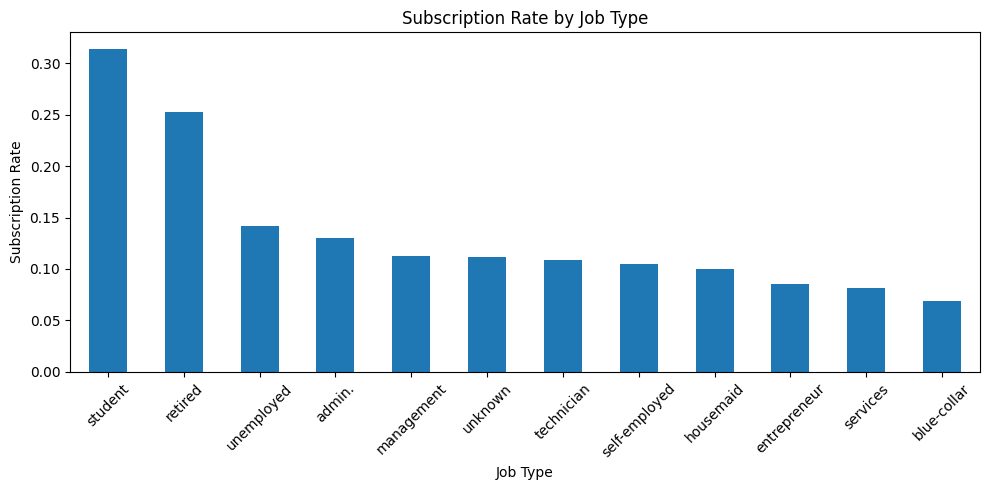

In [19]:
# ============================================================
# Subscription Rate by Job Type
# ============================================================

job_subscription_rate = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
job_subscription_rate.plot(kind="bar")
plt.title("Subscription Rate by Job Type")
plt.ylabel("Subscription Rate")
plt.xlabel("Job Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "subscription_rate_by_job.png"), dpi=300)
plt.show()

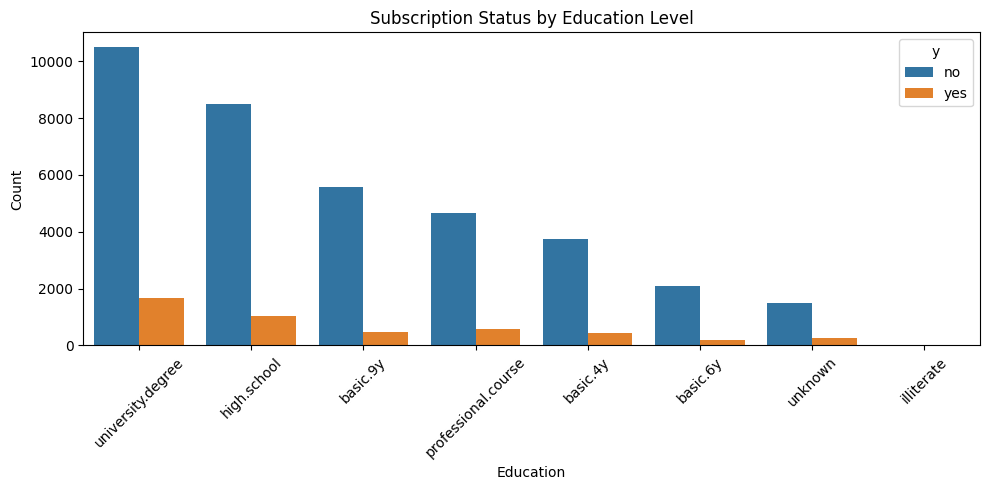

In [20]:
# ============================================================
# Subscription Status by Education
# ============================================================

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="education", hue="y", order=df["education"].value_counts().index)
plt.title("Subscription Status by Education Level")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "subscription_by_education.png"), dpi=300)
plt.show()

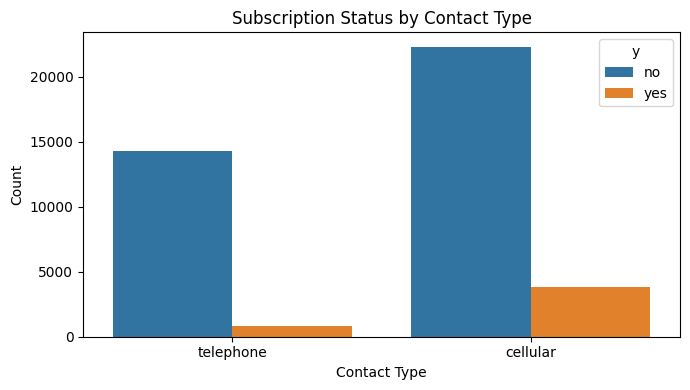

In [21]:
# ============================================================
# Contact Type vs Subscription
# ============================================================

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="contact", hue="y")
plt.title("Subscription Status by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "subscription_by_contact.png"), dpi=300)
plt.show()

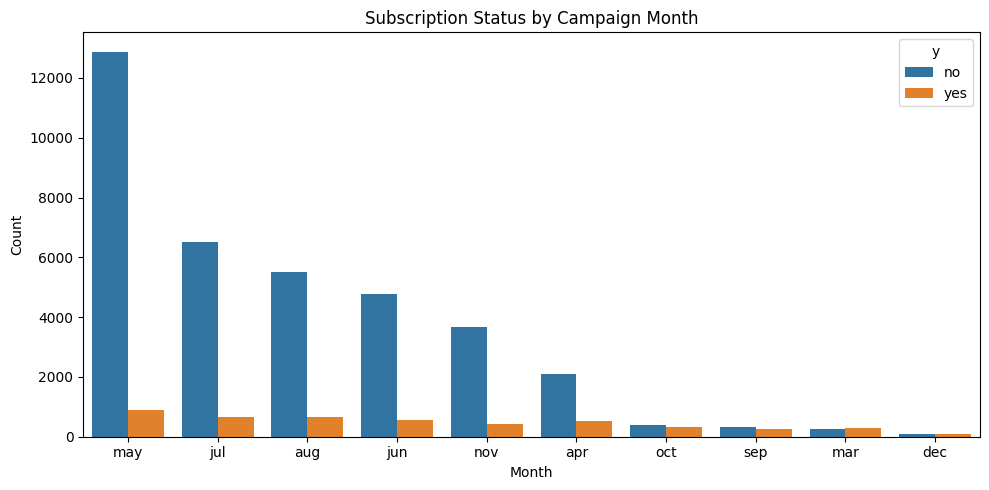

In [22]:
# ============================================================
# Campaign Month vs Subscription
# ============================================================

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="month", hue="y", order=df["month"].value_counts().index)
plt.title("Subscription Status by Campaign Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "subscription_by_month.png"), dpi=300)
plt.show()

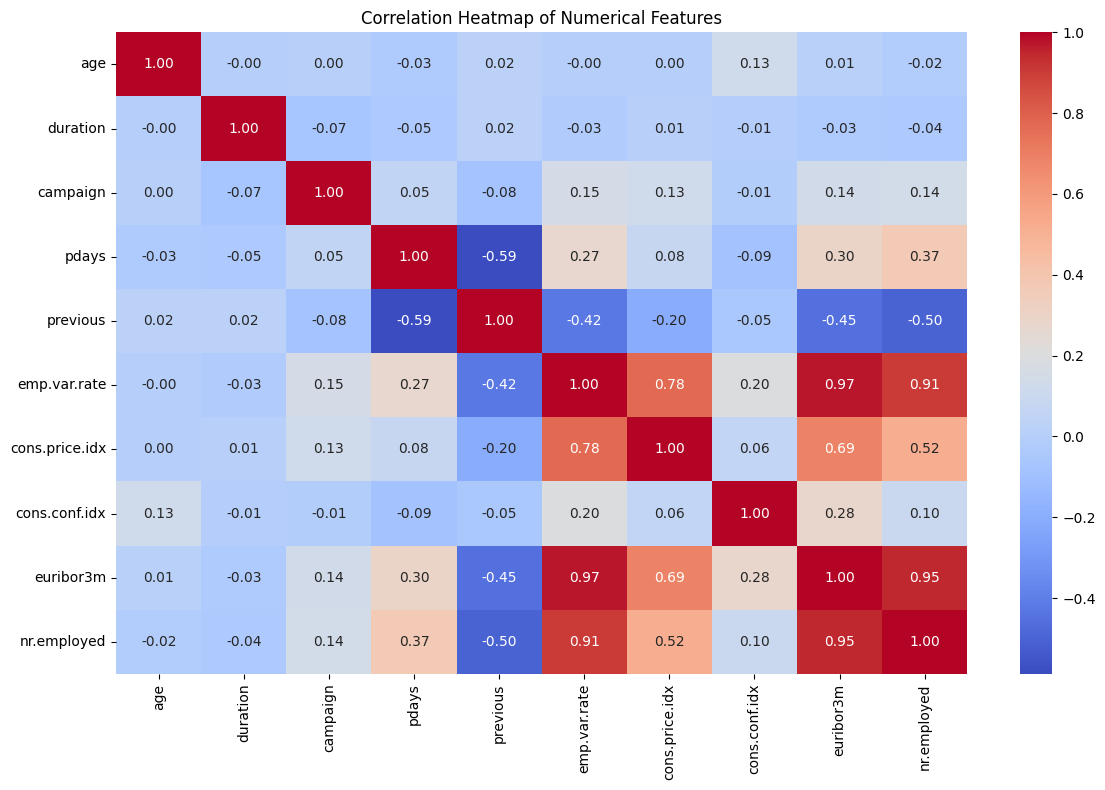

In [23]:
# ============================================================
# Correlation Heatmap for Numerical Features
# ============================================================

plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "correlation_heatmap.png"), dpi=300)
plt.show()

In [24]:
# ============================================================
# Encode Target Variable
# ============================================================

df_model = df.copy()

df_model["y"] = df_model["y"].map({
    "no": 0,
    "yes": 1
})

print("Target distribution:")
display(df_model["y"].value_counts())

print("Target distribution percentage:")
display(df_model["y"].value_counts(normalize=True) * 100)


Target distribution:


,count
y,
0,36537
1,4639


Target distribution percentage:


,proportion
y,
0,88.733728
1,11.266272


In [25]:
# ============================================================
# Feature Engineering - Improved Version
# ============================================================

# We create a new modeling dataframe to avoid modifying the original data by mistake.
df_model_fe = df_model.copy()

# ------------------------------------------------------------
# 1. Previous contact features
# ------------------------------------------------------------
# In this dataset, pdays = 999 means the client was not previously contacted.
# This value is not a normal numeric value, so we represent it explicitly.
df_model_fe["was_contacted_before"] = (df_model_fe["pdays"] != 999).astype(int)
df_model_fe["pdays_clean"] = df_model_fe["pdays"].replace(999, np.nan)

# Previous campaign signal.
df_model_fe["had_previous_campaign"] = (df_model_fe["previous"] > 0).astype(int)
df_model_fe["previous_success"] = (df_model_fe["poutcome"] == "success").astype(int)
df_model_fe["previous_failure"] = (df_model_fe["poutcome"] == "failure").astype(int)

# ------------------------------------------------------------
# 2. Campaign intensity features
# ------------------------------------------------------------
# Log transformations reduce the effect of extreme values.
df_model_fe["campaign_log"] = np.log1p(df_model_fe["campaign"])
df_model_fe["previous_log"] = np.log1p(df_model_fe["previous"])

# Contact intensity: current campaign contacts + previous contacts.
df_model_fe["contact_intensity"] = df_model_fe["campaign"] + df_model_fe["previous"]
df_model_fe["contact_intensity_log"] = np.log1p(df_model_fe["contact_intensity"])

# Clients contacted many times may be less likely to subscribe.
df_model_fe["high_campaign_contact"] = (df_model_fe["campaign"] >= 3).astype(int)

# ------------------------------------------------------------
# 3. Age and calendar features
# ------------------------------------------------------------
# Age groups can help models capture non-linear behavior.
df_model_fe["age_group"] = pd.cut(
    df_model_fe["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["under_25", "25_35", "35_45", "45_55", "55_65", "65_plus"]
).astype("object")

# Season feature from month.
season_map = {
    "mar": "spring", "apr": "spring", "may": "spring",
    "jun": "summer", "jul": "summer", "aug": "summer",
    "sep": "autumn", "oct": "autumn", "nov": "autumn",
    "dec": "winter"
}
df_model_fe["season"] = df_model_fe["month"].map(season_map).astype("object")

# ------------------------------------------------------------
# 4. Economic interaction features
# ------------------------------------------------------------
# These macroeconomic variables are known before the call, so they are not leakage.
# Tree models can learn interactions, but explicit interaction features can still help linear models
# and sometimes improve ensemble performance.
df_model_fe["employment_euribor_interaction"] = (
    df_model_fe["nr.employed"] * df_model_fe["euribor3m"]
)

df_model_fe["economic_pressure"] = (
    df_model_fe["euribor3m"]
    + df_model_fe["emp.var.rate"]
    + df_model_fe["cons.price.idx"]
    - df_model_fe["cons.conf.idx"]
)

# Quick check for engineered features.
engineered_columns = [
    "pdays", "pdays_clean", "was_contacted_before",
    "previous", "previous_log", "had_previous_campaign", "previous_success", "previous_failure",
    "campaign", "campaign_log", "high_campaign_contact", "contact_intensity", "contact_intensity_log",
    "age", "age_group", "month", "season",
    "employment_euribor_interaction", "economic_pressure"
]

display(df_model_fe[engineered_columns].head())


,pdays,pdays_clean,was_contacted_before,previous,previous_log,had_previous_campaign,previous_success,previous_failure,campaign,campaign_log,high_campaign_contact,contact_intensity,contact_intensity_log,age,age_group,month,season,employment_euribor_interaction,economic_pressure
0,999,NaN,0,0,0.0,0,0,0,1,0.693147,0,1,0.693147,56,55_65,may,spring,25212.687,136.351
1,999,NaN,0,0,0.0,0,0,0,1,0.693147,0,1,0.693147,57,55_65,may,spring,25212.687,136.351
2,999,NaN,0,0,0.0,0,0,0,1,0.693147,0,1,0.693147,37,35_45,may,spring,25212.687,136.351
3,999,NaN,0,0,0.0,0,0,0,1,0.693147,0,1,0.693147,40,35_45,may,spring,25212.687,136.351
4,999,NaN,0,0,0.0,0,0,0,1,0.693147,0,1,0.693147,56,55_65,may,spring,25212.687,136.351


In [27]:
# ============================================================
# Feature Selection
# ============================================================

target = "y"

# duration is removed because it is only known after the phone call.
# Keeping duration would cause data leakage for real-world pre-call prediction.
# pdays is removed because we replaced it with pdays_clean and was_contacted_before.
features_to_drop = [
    target,
    "duration",
    "pdays"
]

X = df_model_fe.drop(columns=features_to_drop)
y = df_model_fe[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("Required engineered columns check:")
for col in [
    "was_contacted_before", "pdays_clean", "age_group", "season",
    "had_previous_campaign", "previous_success", "contact_intensity_log",
    "employment_euribor_interaction", "economic_pressure"
]:
    print(f"{col} in X:", col in X.columns)

display(X.head())


Feature matrix shape: (41176, 32)
Target shape: (41176,)
Required engineered columns check:
was_contacted_before in X: True
pdays_clean in X: True
age_group in X: True
season in X: True
had_previous_campaign in X: True
previous_success in X: True
contact_intensity_log in X: True
employment_euribor_interaction in X: True
economic_pressure in X: True


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,pdays_clean,had_previous_campaign,previous_success,previous_failure,campaign_log,previous_log,contact_intensity,contact_intensity_log,high_campaign_contact,age_group,season,employment_euribor_interaction,economic_pressure
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0,0,0,0.693147,0.0,1,0.693147,0,55_65,spring,25212.687,136.351
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0,0,0,0.693147,0.0,1,0.693147,0,55_65,spring,25212.687,136.351
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0,0,0,0.693147,0.0,1,0.693147,0,35_45,spring,25212.687,136.351
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0,0,0,0.693147,0.0,1,0.693147,0,35_45,spring,25212.687,136.351
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,NaN,0,0,0,0.693147,0.0,1,0.693147,0,55_65,spring,25212.687,136.351


In [28]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

# 60% train, 20% validation, 20% test
# stratify keeps the same target distribution in all splits.
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print()
print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print()
print("Validation target distribution:")
print(y_val.value_counts(normalize=True))

print()
print("Test target distribution:")
print(y_test.value_counts(normalize=True))

print()
print("Column check after split:")
print("was_contacted_before in X_train:", "was_contacted_before" in X_train.columns)
print("pdays_clean in X_train:", "pdays_clean" in X_train.columns)
print("age_group in X_train:", "age_group" in X_train.columns)


X_train shape: (24705, 32)
X_val shape: (8235, 32)
X_test shape: (8236, 32)

Train target distribution:
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64

Validation target distribution:
y
0    0.88731
1    0.11269
Name: proportion, dtype: float64

Test target distribution:
y
0    0.887324
1    0.112676
Name: proportion, dtype: float64

Column check after split:
was_contacted_before in X_train: True
pdays_clean in X_train: True
age_group in X_train: True


In [29]:
# ============================================================
# Class Imbalance Ratio
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", scale_pos_weight)


Negative samples: 21922
Positive samples: 2783
scale_pos_weight: 7.8771110312612285


In [30]:
# ============================================================
# Identify Numerical and Categorical Features for Modeling
# ============================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print()
print("Categorical features:")
print(categorical_features)


Numeric features:
['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before', 'pdays_clean', 'had_previous_campaign', 'previous_success', 'previous_failure', 'campaign_log', 'previous_log', 'contact_intensity', 'contact_intensity_log', 'high_campaign_contact', 'employment_euribor_interaction', 'economic_pressure']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'age_group', 'season']


In [31]:
# ============================================================
# Preprocessing Pipeline
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'campaign', 'previous', 'emp.var.rate',
                                  'cons.price.idx', 'cons.conf.idx',
                                  'euribor3m', 'nr.employed',
                                  'was_contacted_before', 'pdays_clean',
                                  'had_previous_campaign', 'previous_success',
                                  'previous_failure', 'campaign_log',
                                  'pr...
                                  'contact_intensity_log',
                                  'high_campaign_contact',
                                  'employment_euribor_interaction',
                                  'economic_pressure']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'day_of_week', 'poutcome', 'age_group',
                                  'season'])])

In [32]:
# ============================================================
# Model Evaluation Function
# ============================================================

def evaluate_model(model, X_data, y_data, model_name, threshold=0.5):
    """
    Evaluates a classification model using multiple metrics.

    For imbalanced classification, accuracy alone is not enough.
    F1-score, recall, ROC-AUC and PR-AUC are more informative.
    """

    y_proba = model.predict_proba(X_data)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_data, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_data, y_pred),
        "precision": precision_score(y_data, y_pred, zero_division=0),
        "recall": recall_score(y_data, y_pred, zero_division=0),
        "f1_score": f1_score(y_data, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_data, y_proba),
        "pr_auc": average_precision_score(y_data, y_proba)
    }

    print("=" * 70)
    print(f"Model: {model_name}")
    print(f"Threshold: {threshold:.4f}")
    print("=" * 70)
    print(classification_report(y_data, y_pred, zero_division=0))
    print("ROC-AUC:", metrics["roc_auc"])
    print("PR-AUC:", metrics["pr_auc"])

    return metrics


In [33]:
# ============================================================
# Define Candidate Machine Learning Models - Improved Version
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=14,
        min_samples_split=10,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=16,
        min_samples_split=10,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=350,
        learning_rate=0.025,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

# XGBoost is usually stronger than classic GradientBoosting on tabular data.
# It also supports scale_pos_weight, which is useful for imbalanced classification.
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=600,
        learning_rate=0.025,
        max_depth=4,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        reg_alpha=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

models.keys()


dict_keys(['Logistic Regression', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost'])

In [34]:
# ============================================================
# Train and Evaluate Models on Validation Set
# ============================================================

trained_models = {}
model_results = []

for model_name, classifier in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ]
    )

    print(f"Training {model_name}...")
    pipeline.fit(X_train, y_train)

    metrics = evaluate_model(
        pipeline,
        X_val,
        y_val,
        model_name,
        threshold=0.5
    )

    trained_models[model_name] = pipeline
    model_results.append(metrics)

metrics_df = pd.DataFrame(model_results)
metrics_df = metrics_df.sort_values(by="pr_auc", ascending=False)

display(metrics_df)


Training Logistic Regression...
Model: Logistic Regression
Threshold: 0.5000
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7307
           1       0.37      0.63      0.46       928

    accuracy                           0.84      8235
   macro avg       0.66      0.74      0.68      8235
weighted avg       0.88      0.84      0.85      8235

ROC-AUC: 0.8040590063614012
PR-AUC: 0.44983631372089966
Training Random Forest...
Model: Random Forest
Threshold: 0.5000
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      7307
           1       0.44      0.57      0.50       928

    accuracy                           0.87      8235
   macro avg       0.69      0.74      0.71      8235
weighted avg       0.89      0.87      0.88      8235

ROC-AUC: 0.8078530477388237
PR-AUC: 0.45441946439417047
Training Extra Trees...
Model: Extra Trees
Threshold: 0.5000
              precision    reca

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc
3,Gradient Boosting,0.5,0.902732,0.624400,0.673973,0.265086,0.380510,0.810562,0.463095
4,XGBoost,0.5,0.843352,0.752745,0.382620,0.635776,0.477733,0.810179,0.461077
1,Random Forest,0.5,0.871281,0.739321,0.444444,0.568966,0.499055,0.807853,0.454419
2,Extra Trees,0.5,0.864238,0.737233,0.424242,0.573276,0.487626,0.804055,0.450004
0,Logistic Regression,0.5,0.835216,0.744868,0.365517,0.628233,0.462148,0.804059,0.449836


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc
3,Gradient Boosting,0.5,0.902732,0.624400,0.673973,0.265086,0.380510,0.810562,0.463095
4,XGBoost,0.5,0.843352,0.752745,0.382620,0.635776,0.477733,0.810179,0.461077
1,Random Forest,0.5,0.871281,0.739321,0.444444,0.568966,0.499055,0.807853,0.454419
2,Extra Trees,0.5,0.864238,0.737233,0.424242,0.573276,0.487626,0.804055,0.450004
0,Logistic Regression,0.5,0.835216,0.744868,0.365517,0.628233,0.462148,0.804059,0.449836


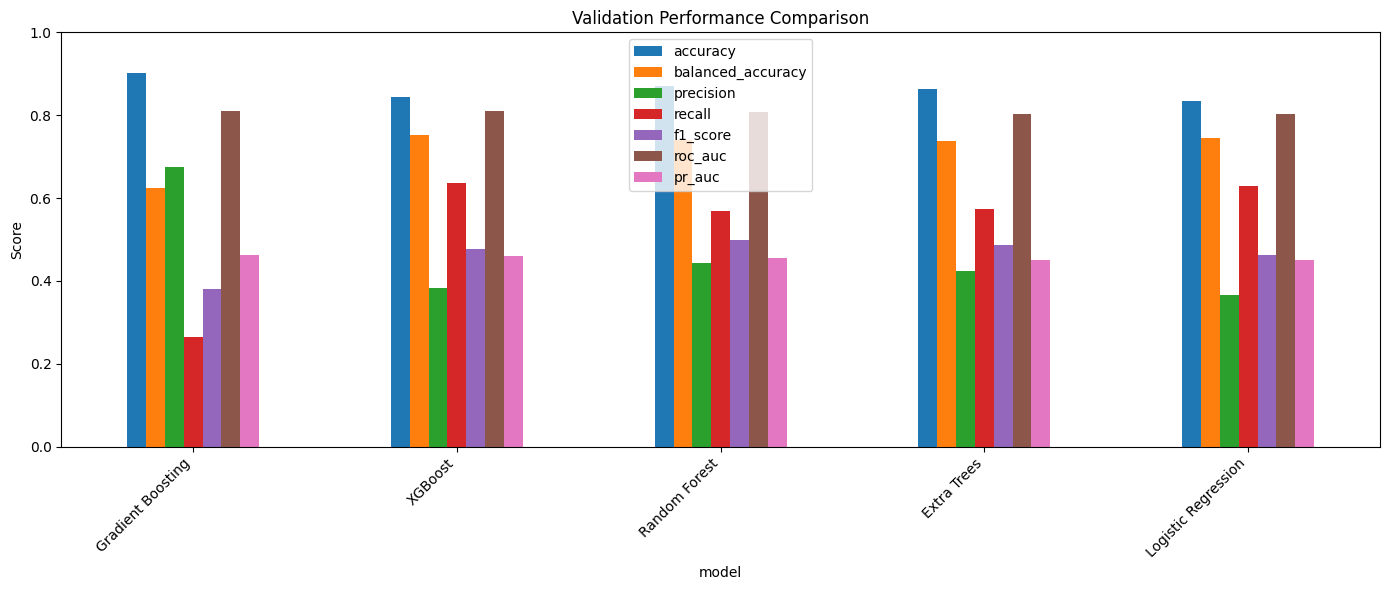

In [35]:
# ============================================================
# Model Performance Comparison on Validation Set
# ============================================================

display(metrics_df)

metrics_plot_df = metrics_df.set_index("model")[
    ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]
]

ax = metrics_plot_df.plot(kind="bar", figsize=(14, 6))
ax.set_title("Validation Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "validation_model_comparison.png"), dpi=300)
plt.show()


In [36]:
# ============================================================
# Select Best Baseline Model Based on Validation PR-AUC
# ============================================================

best_baseline_model_name = metrics_df.iloc[0]["model"]
best_baseline_model = trained_models[best_baseline_model_name]

print("Best baseline model based on validation PR-AUC:", best_baseline_model_name)


Best baseline model based on validation PR-AUC: Gradient Boosting


## Hyperparameter Tuning

We tune Random Forest using **average precision / PR-AUC**, because the dataset is imbalanced. This is more suitable than selecting only by accuracy.


In [37]:
# ============================================================
# Fast Hyperparameter Tuning for Random Forest
# ============================================================

# Heavy tuning can take 30+ minutes and usually gives only a small gain on this dataset.
# This faster search is more practical for a GitHub/portfolio notebook.

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

param_dist = {
    "classifier__n_estimators": [300, 500],
    "classifier__max_depth": [12, 16, 20],
    "classifier__min_samples_split": [5, 10],
    "classifier__min_samples_leaf": [2, 4, 6],
    "classifier__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("Best CV PR-AUC:")
print(random_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 6, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 12}
Best CV PR-AUC:
0.459800281807377


In [40]:
# ============================================================
# Evaluate Tuned Random Forest on Validation Set
# ============================================================

tuned_rf_model = random_search.best_estimator_

tuned_rf_val_metrics = evaluate_model(
    tuned_rf_model,
    X_val,
    y_val,
    "Tuned Random Forest",
    threshold=0.5
)

display(pd.DataFrame([tuned_rf_val_metrics]))


Model: Tuned Random Forest
Threshold: 0.5000
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      7307
           1       0.43      0.62      0.50       928

    accuracy                           0.86      8235
   macro avg       0.69      0.76      0.71      8235
weighted avg       0.89      0.86      0.87      8235

ROC-AUC: 0.8143666412226348
PR-AUC: 0.46386646532320575


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Tuned Random Forest,0.5,0.863509,0.755167,0.426756,0.615302,0.503972,0.814367,0.463866


In [41]:
# ============================================================
# Final Model Selection Using Validation PR-AUC
# ============================================================

comparison_df = pd.concat([
    metrics_df,
    pd.DataFrame([tuned_rf_val_metrics])
], ignore_index=True)

comparison_df = comparison_df.sort_values(by="pr_auc", ascending=False)
display(comparison_df)

final_model_name = comparison_df.iloc[0]["model"]

if final_model_name == "Tuned Random Forest":
    final_model = tuned_rf_model
else:
    final_model = trained_models[final_model_name]

print("Final selected model based on validation PR-AUC:", final_model_name)


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc
5,Tuned Random Forest,0.5,0.863509,0.755167,0.426756,0.615302,0.503972,0.814367,0.463866
0,Gradient Boosting,0.5,0.902732,0.624400,0.673973,0.265086,0.380510,0.810562,0.463095
1,XGBoost,0.5,0.843352,0.752745,0.382620,0.635776,0.477733,0.810179,0.461077
2,Random Forest,0.5,0.871281,0.739321,0.444444,0.568966,0.499055,0.807853,0.454419
3,Extra Trees,0.5,0.864238,0.737233,0.424242,0.573276,0.487626,0.804055,0.450004
4,Logistic Regression,0.5,0.835216,0.744868,0.365517,0.628233,0.462148,0.804059,0.449836


Final selected model based on validation PR-AUC: Tuned Random Forest


## Threshold Tuning

Threshold tuning is performed on the **validation set only**. This avoids leaking information from the test set.


In [43]:
# ============================================================
# Threshold Tuning on Validation Set
# ============================================================

val_proba = final_model.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions[:-1],
    "recall": recalls[:-1]
})

threshold_df["f1_score"] = (
    2 * threshold_df["precision"] * threshold_df["recall"]
) / (
    threshold_df["precision"] + threshold_df["recall"] + 1e-9
)

threshold_df = threshold_df.sort_values(by="f1_score", ascending=False)

display(threshold_df.head(10))

best_threshold = threshold_df.iloc[0]["threshold"]

print("Best threshold selected on validation set:", best_threshold)


,threshold,precision,recall,f1_score
6887,0.537474,0.445957,0.600216,0.511713
6890,0.538987,0.446228,0.599138,0.511500
6886,0.537014,0.445600,0.600216,0.511478
6889,0.538420,0.445870,0.599138,0.511264
6885,0.536216,0.445244,0.600216,0.511244
6888,0.538409,0.445513,0.599138,0.511029
6884,0.536139,0.444888,0.600216,0.511009
6891,0.539176,0.445783,0.598060,0.510815
6883,0.536038,0.444533,0.600216,0.510775
6882,0.535971,0.444179,0.600216,0.510541


Best threshold selected on validation set: 0.5374739893725333


In [44]:
# ============================================================
# Final Evaluation on Test Set
# ============================================================

# The test set is used only once here for the final unbiased evaluation.
final_metrics = evaluate_model(
    final_model,
    X_test,
    y_test,
    f"{final_model_name} + Validation Threshold",
    threshold=best_threshold
)

final_metrics_df = pd.DataFrame([final_metrics])
display(final_metrics_df)


Model: Tuned Random Forest + Validation Threshold
Threshold: 0.5375
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7308
           1       0.46      0.62      0.53       928

    accuracy                           0.88      8236
   macro avg       0.71      0.76      0.73      8236
weighted avg       0.89      0.88      0.88      8236

ROC-AUC: 0.8161059620538663
PR-AUC: 0.48297518311149906


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Tuned Random Forest + Validation Threshold,0.537474,0.875911,0.762153,0.461974,0.615302,0.527726,0.816106,0.482975


## Business-Oriented Threshold Selection

The F1 threshold gives a balanced trade-off. In a bank marketing campaign, however, the business may prefer to find more potential subscribers even if it creates more false positives. The next cell selects a recall-oriented threshold.


In [45]:
# ============================================================
# Business Threshold Selection: Recall-Oriented Strategy
# ============================================================

# Target: find more real subscribers.
# If no threshold reaches this recall level, the code falls back to the best F1 threshold.
target_recall = 0.65

business_candidates = threshold_df[
    threshold_df["recall"] >= target_recall
].sort_values(by="precision", ascending=False)

if len(business_candidates) > 0:
    business_threshold = business_candidates.iloc[0]["threshold"]
    print("Business threshold selected for recall >=", target_recall, ":", business_threshold)
    display(business_candidates.head(10))
else:
    business_threshold = best_threshold
    print("No threshold reached target recall. Using best F1 threshold:", business_threshold)

business_metrics = evaluate_model(
    final_model,
    X_test,
    y_test,
    f"{final_model_name} + Business Threshold",
    threshold=business_threshold
)

business_metrics_df = pd.DataFrame([business_metrics])
display(business_metrics_df)


Business threshold selected for recall >= 0.65 : 0.41592600020773574


,threshold,precision,recall,f1_score
6494,0.415926,0.366950,0.650862,0.469308
6493,0.415475,0.366727,0.650862,0.469126
6490,0.414882,0.366667,0.651940,0.469356
6492,0.415254,0.366505,0.650862,0.468944
6489,0.414418,0.366445,0.651940,0.469174
6491,0.415100,0.366283,0.650862,0.468762
6488,0.414408,0.366223,0.651940,0.468992
6487,0.414403,0.366001,0.651940,0.468811
6486,0.413767,0.365780,0.651940,0.468629
6485,0.413344,0.365559,0.651940,0.468448


Model: Tuned Random Forest + Business Threshold
Threshold: 0.4159
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7308
           1       0.38      0.67      0.48       928

    accuracy                           0.84      8236
   macro avg       0.67      0.76      0.69      8236
weighted avg       0.89      0.84      0.86      8236

ROC-AUC: 0.8161059620538663
PR-AUC: 0.48297518311149906


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Tuned Random Forest + Business Threshold,0.415926,0.83815,0.764864,0.377198,0.670259,0.482732,0.816106,0.482975


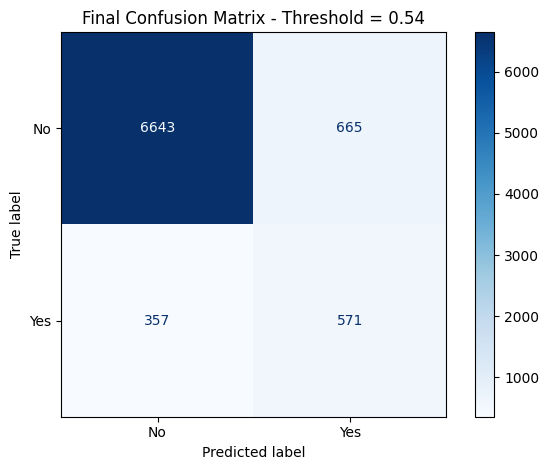

In [46]:
# ============================================================
# Final Confusion Matrix
# ============================================================

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")
plt.title(f"Final Confusion Matrix - Threshold = {best_threshold:.2f}")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "final_confusion_matrix.png"), dpi=300)
plt.show()


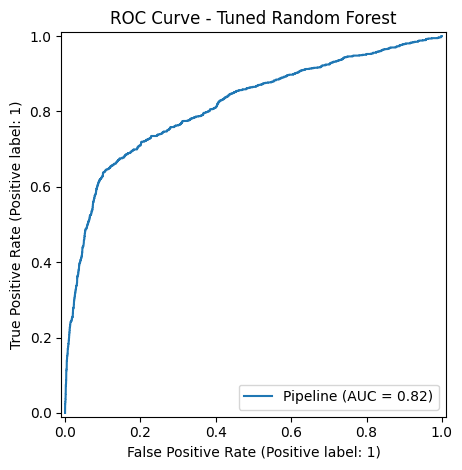

In [47]:
# ============================================================
# Final ROC Curve
# ============================================================

RocCurveDisplay.from_estimator(final_model, X_test, y_test)

plt.title(f"ROC Curve - {final_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "final_roc_curve.png"), dpi=300)
plt.show()


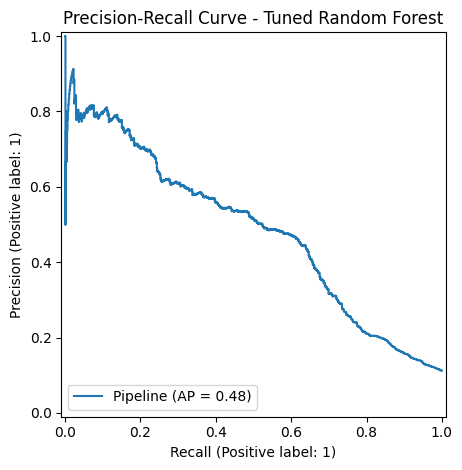

In [48]:
# ============================================================
# Final Precision-Recall Curve
# ============================================================

PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test)

plt.title(f"Precision-Recall Curve - {final_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "final_precision_recall_curve.png"), dpi=300)
plt.show()


,feature,importance
18,num__employment_euribor_interaction,0.127348
19,num__economic_pressure,0.121541
6,num__euribor3m,0.100851
7,num__nr.employed,0.094049
3,num__emp.var.rate,0.056545
5,num__cons.conf.idx,0.040845
0,num__age,0.033842
72,cat__poutcome_success,0.027582
4,num__cons.price.idx,0.027372
8,num__was_contacted_before,0.023493


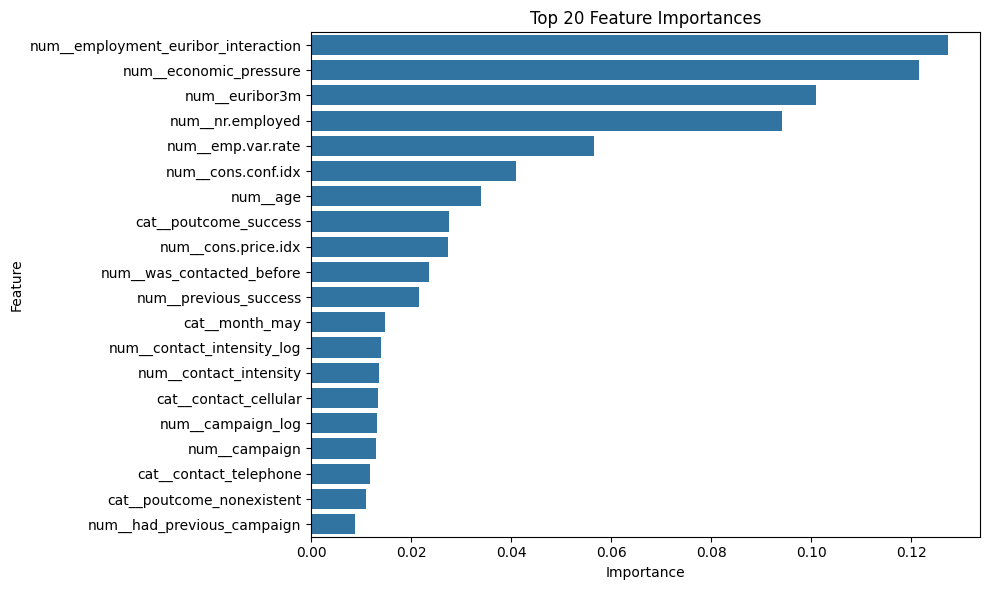

In [49]:
# ============================================================
# Feature Importance
# ============================================================

classifier = final_model.named_steps["classifier"]
preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

if hasattr(classifier, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": classifier.feature_importances_
    }).sort_values(by="importance", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_df.head(20),
        x="importance",
        y="feature"
    )
    plt.title("Top 20 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, "feature_importance.png"), dpi=300)
    plt.show()
else:
    print("Selected model does not provide feature_importances_.")
    print("This is normal for Logistic Regression or some other models.")


In [50]:
# ============================================================
# Save Final Model
# ============================================================

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "bank_marketing_final_model.pkl")

joblib.dump(
    {
        "model": final_model,
        "threshold": best_threshold,
        "features": X.columns.tolist(),
        "metrics": final_metrics
    },
    model_path
)

print(f"Final model saved to: {model_path}")


Final model saved to: models/bank_marketing_final_model.pkl


# Final Notes for GitHub README

Use this explanation in your README:

The project predicts whether a bank client will subscribe to a term deposit. Since the target class is imbalanced, the model is evaluated using F1-score, recall, ROC-AUC and PR-AUC instead of accuracy alone. The `duration` feature is removed to avoid data leakage because it is only known after a call is completed. The `pdays = 999` value is handled with feature engineering because it means the client was not previously contacted. Models are selected on the validation set, threshold tuning is performed on the validation set, and the test set is used only once for final unbiased evaluation.


## Optional Leakage Experiment With `duration`

This experiment intentionally includes `duration`. It is useful for learning because it shows why many public examples get much higher scores. However, this model is not deployable for pre-call prediction because `duration` is only known after the phone call ends.


In [51]:
# ============================================================
# Optional Experiment: Model With Duration Feature
# WARNING: This causes data leakage for pre-call prediction.
# ============================================================

X_leakage = df_model_fe.drop(columns=["y", "pdays"])
y_leakage = df_model_fe["y"]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leakage,
    y_leakage,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_leakage
)

numeric_features_l = X_leakage.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_l = X_leakage.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor_l = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_l),
        ("cat", categorical_transformer, categorical_features_l)
    ]
)

leakage_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_l),
        ("classifier", GradientBoostingClassifier(
            n_estimators=350,
            learning_rate=0.025,
            max_depth=3,
            random_state=RANDOM_STATE
        ))
    ]
)

leakage_model.fit(X_train_l, y_train_l)

leakage_metrics = evaluate_model(
    leakage_model,
    X_test_l,
    y_test_l,
    "Gradient Boosting With Duration - Leakage Experiment",
    threshold=0.5
)

leakage_metrics_df = pd.DataFrame([leakage_metrics])
display(leakage_metrics_df)


Model: Gradient Boosting With Duration - Leakage Experiment
Threshold: 0.5000
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7308
           1       0.66      0.55      0.60       928

    accuracy                           0.92      8236
   macro avg       0.80      0.75      0.78      8236
weighted avg       0.91      0.92      0.91      8236

ROC-AUC: 0.9494576237897061
PR-AUC: 0.6589096744592636


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Gradient Boosting With Duration - Leakage Expe...,0.5,0.91695,0.754704,0.658854,0.545259,0.596698,0.949458,0.65891
